# Test of origin of replication deconvolution with fixed offset configs

In [214]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1048]:
o = origins.sort_values(eff_key, ascending=False)
o = o[o.activation_time == 'late']
o

,chr,pos,strand,footprint_class,nucleosome_shift_class,mcm_loading_class,activation_time,derived_origin_efficiency_from_mcguffee_et_al_2013,acs_sequence,log2_acs_motif_score,ars_name,ars_start,ars_end,oridb_status
name,,,,,,,,,,,,,,
oridb_126,4,123794,-,g1_and_g2_footprint,downstream,upstream,late,0.8108,TTAATATATATTTAGTTACTTTTTCCCTCTAAT,15.4106,ARS406,123616,123901,Confirmed
oridb_498,11,612412,-,g1_and_g2_footprint,static,downstream,late,0.7361,TTTTTTTATGTTTTTGGCTCCTAGAGGTGAATA,14.0135,ARS1120,612240,612473,Confirmed
oridb_193,4,1353585,+,g1_and_g2_footprint,upstream,upstream,late,0.7143,CAAATTAATATTTATGAACGTTATGATGTCAAG,8.0574,ARS437,1353506,1353679,Confirmed
oridb_558,12,888741,-,g1_and_g2_footprint,downstream,downstream,late,0.7121,GTTTTTTATGTTTAGATGTAAAAATTAATTTTT,20.0399,ARS1227.5,888569,888810,Confirmed
oridb_121,4,46229,-,g1_and_g2_footprint,static,upstream,late,0.6938,AAATTTAATATTTTGGATGAAAAAAACCATTTT,11.5099,ARS404,46180,46236,Confirmed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oridb_807,16,608624,-,g1_and_g2_footprint,static,downstream,late,-0.3633,TATATTTTATTTTTGTTATTTTTCTGACGTATC,10.2164,NaN,608479,609679,Dubious
oridb_94,3,54938,-,g1_and_g2_footprint,downstream,upstream,late,-0.5451,CTTTTTTTTTTTTTGTTACATAAAACTTTGCTT,9.1369,NaN,53807,55007,Dubious
oridb_336,8,7756,-,g1_and_g2_footprint,static,downstream,late,-1.0000,TATTTTTATATTTAGGTGATTTTAGTGGTTATT,23.2374,ARS802,7535,7783,Confirmed


In [1513]:
def deconvolve_and_plot_model(origin_sweep, config_mode, title, selected_origins,
                             gamma=0.01, impute_50=True):
    """
    Create a single plot for a model with multiple origins as rows
    """    
    # Create a figure with 4 rows (one for each origin) and 3 columns 
    # (replicates 1, 2, combined)
    fig, axes = plt.subplots(len(selected_origins), 5, 
                             figsize=(16, 3 * len(selected_origins)))
    
    # Process each origin
    for row, oridb in enumerate(selected_origins):
                
        # Analyze the origin
        footprint = origin_sweep.analyze_origin(oridb, impute_50_rep2=impute_50)
        
        # ------------- Raw data ----------------------------------
        from src.helpers import plot_raw_timepoints
        footprint_means = origin_sweep.footprint.mean((1, 2))

        tp1 = origin_sweep.config1.timepoints
        tp2 = origin_sweep.config2.timepoints

        plt.sca(axes[row][0])
        plt.plot(tp1, footprint_means[:len(tp1)], label='WT1')
        plot_raw_timepoints(origin_sweep.config1)
        plt.title("Replicate 1")
        plt.ylim(0, 2.5)
        plt.ylabel(f"Origin {oridb}", fontsize=12)
        if row < len(selected_origins)-1: plt.xticks([])

        plt.sca(axes[row][1])
        plt.plot(tp2, footprint_means[len(tp1):], label="WT2")
        plot_raw_timepoints(origin_sweep.config2)
        plt.title("Replicate 2")
        plt.ylim(0, 2.5)
        plt.yticks([])
        if row < len(selected_origins)-1: plt.xticks([])
                
        # ------------------------------------------------------------
            
        # For each replicate type (1, 2, combined)
        for col, replicate in enumerate([1, 2, 'combined']):

            # Set the current subplot
            plt.sca(axes[row][col+2])                
            plt.yticks([])

            if row < len(selected_origins)-1: plt.xticks([])
            
            # Set up and perform deconvolution
            origin_sweep.setup_footprint_deconvolution(replicate=replicate)
            origin_sweep.deconvolve_footprint(gamma=gamma)
            
            # Plot the results
            origin_sweep.plot_deconvolved_footprint(fig=fig)
            
            # Set y-axis limits
            plt.ylim(0, 2.5)
    
    # Add overall title
    plt.suptitle(title, y=1.015, fontweight='demi', fontsize=16)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure
    from src.figure_configs import save_figure_for_paper
    save_figure_for_paper(f'output/origins_model_comparison/{title.replace(":", "_")}.png')
    
    return fig


In [1514]:
# origin_sweep.print_efficient_origins()
selected_origins = [
#    'oridb_10', # ARS107 
#    'oridb_295', # ARS718
   'oridb_289',
    'oridb_193', # late
    'oridb_558', # late
    'oridb_498', # ARS1120, late
]

Loading chromosome reads: 7
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 7
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1000) to (15, 26, 100)
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data f

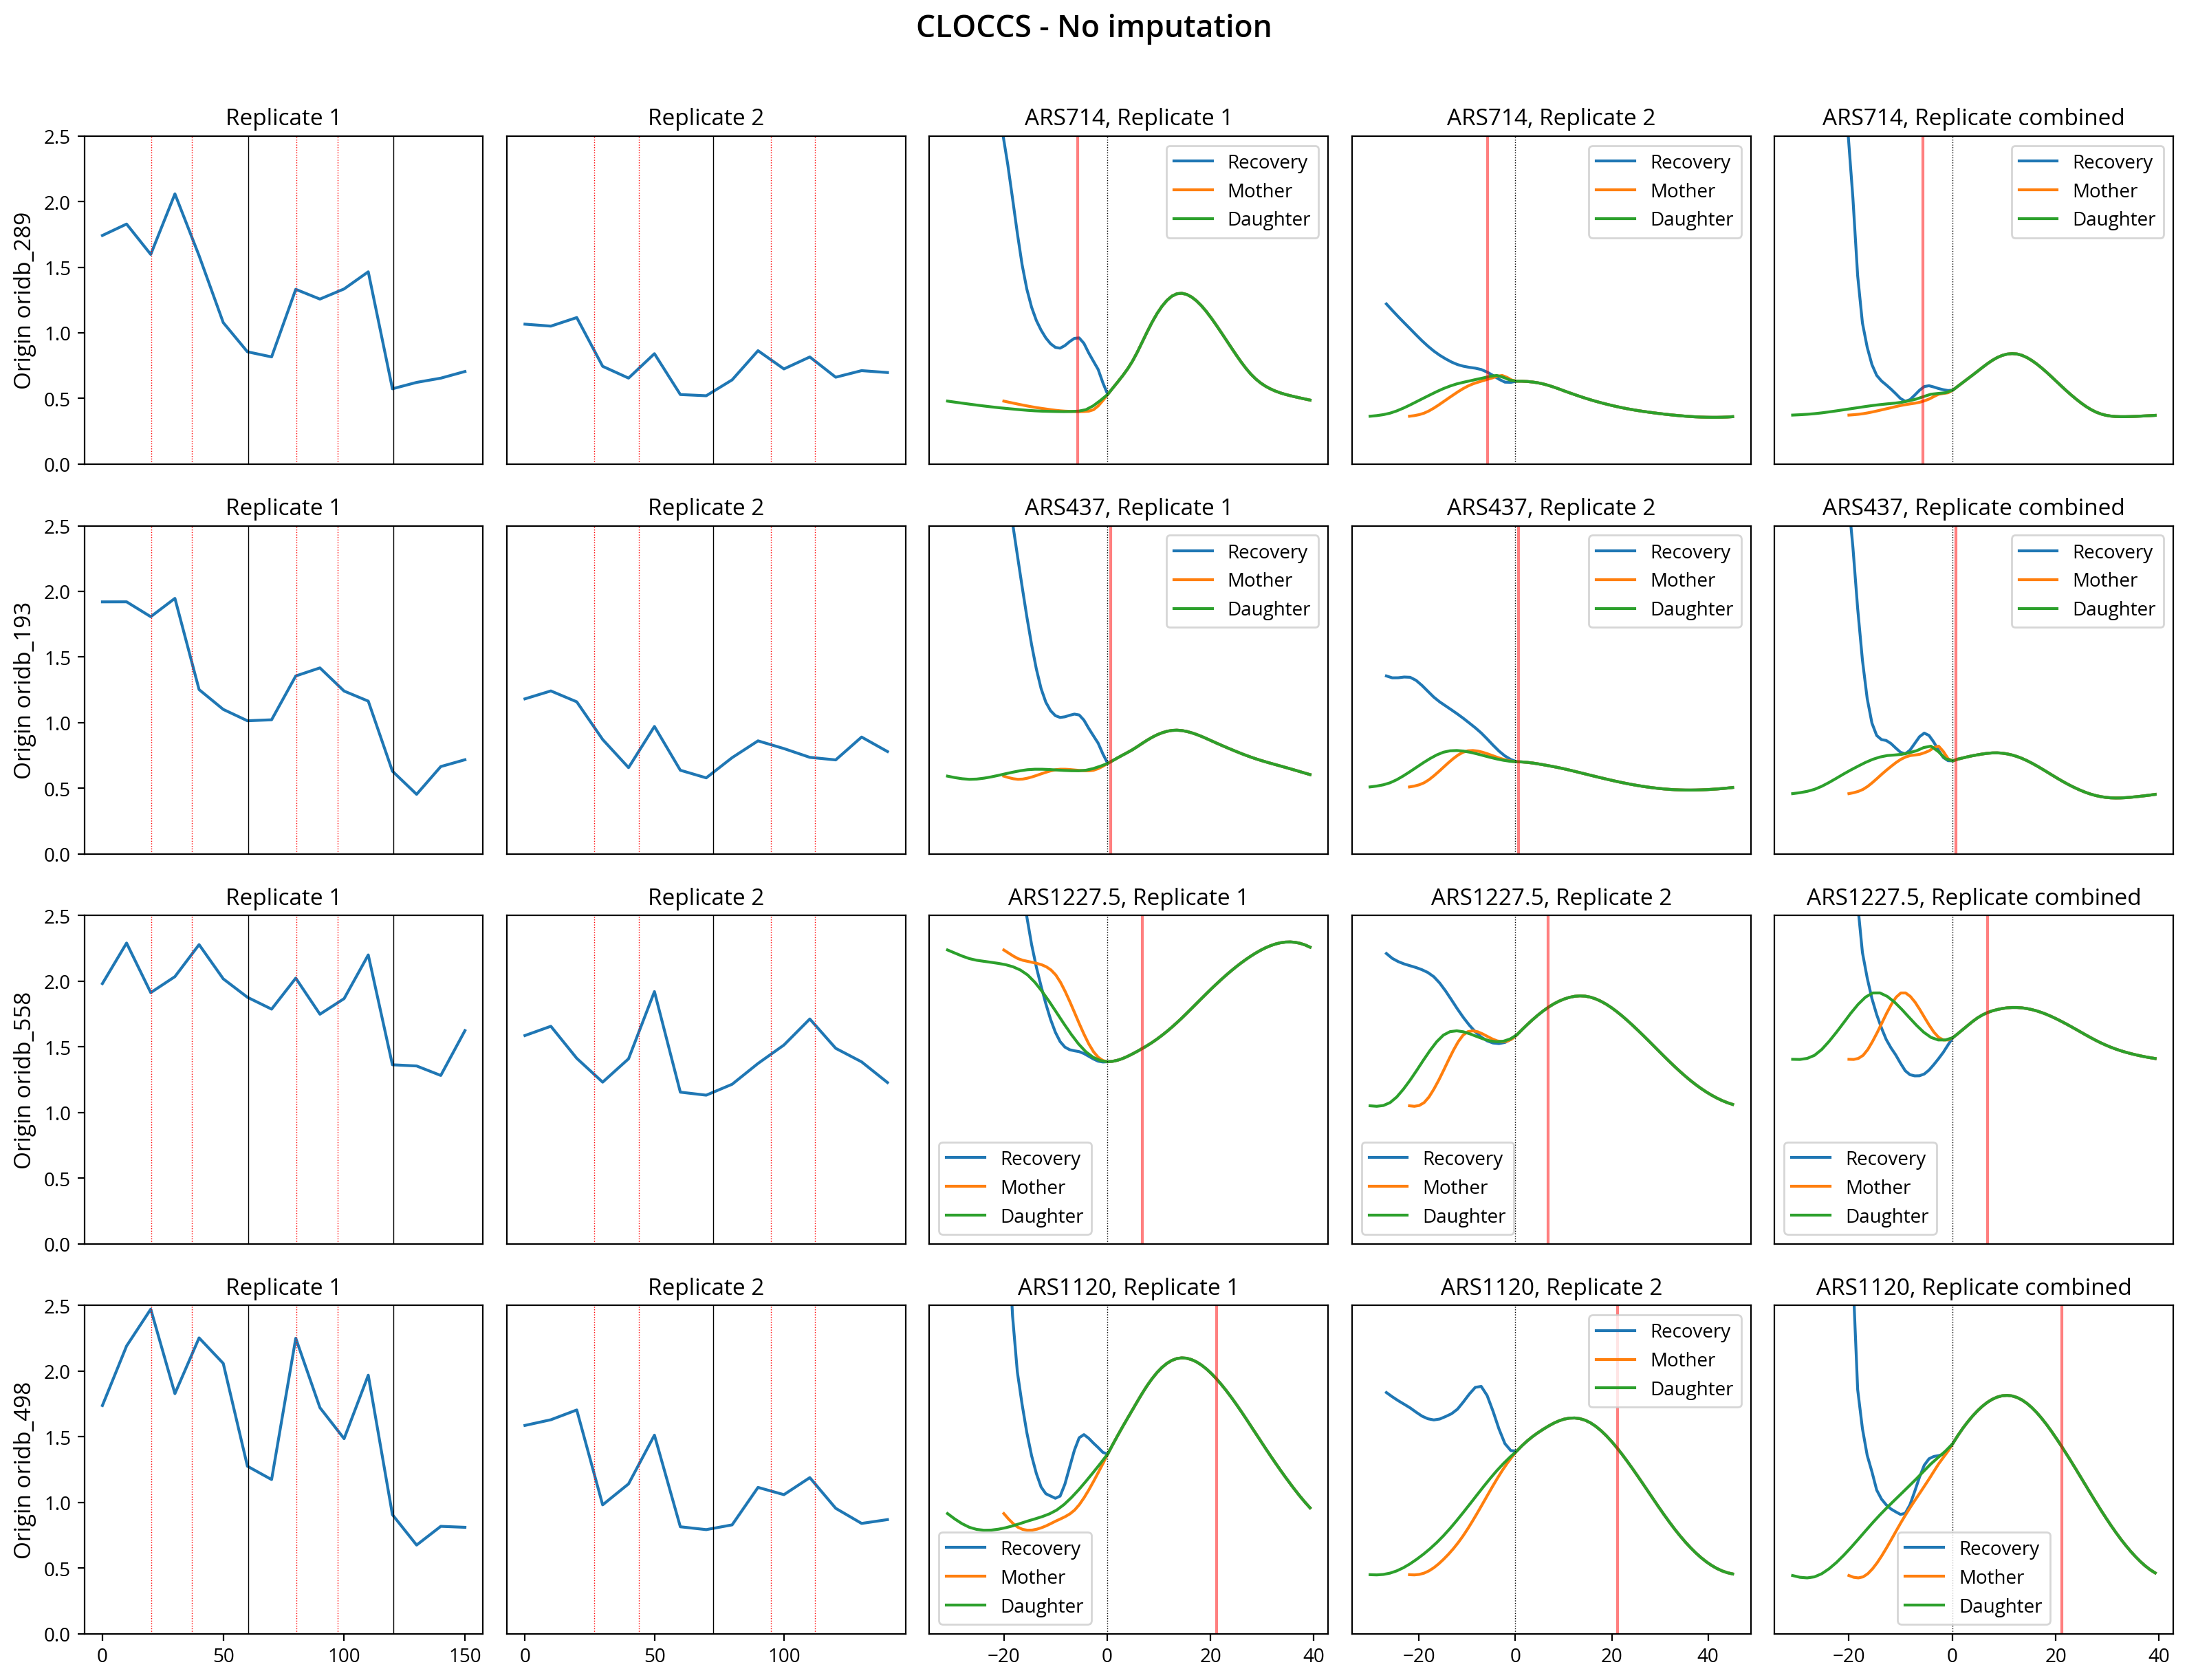

Loading chromosome reads: 7
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 7
Imputing timepoint 50 as average of 40 and 60
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1000) to (15, 26, 100)
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Loading copy correction N, Fr, B from output/draft3_r

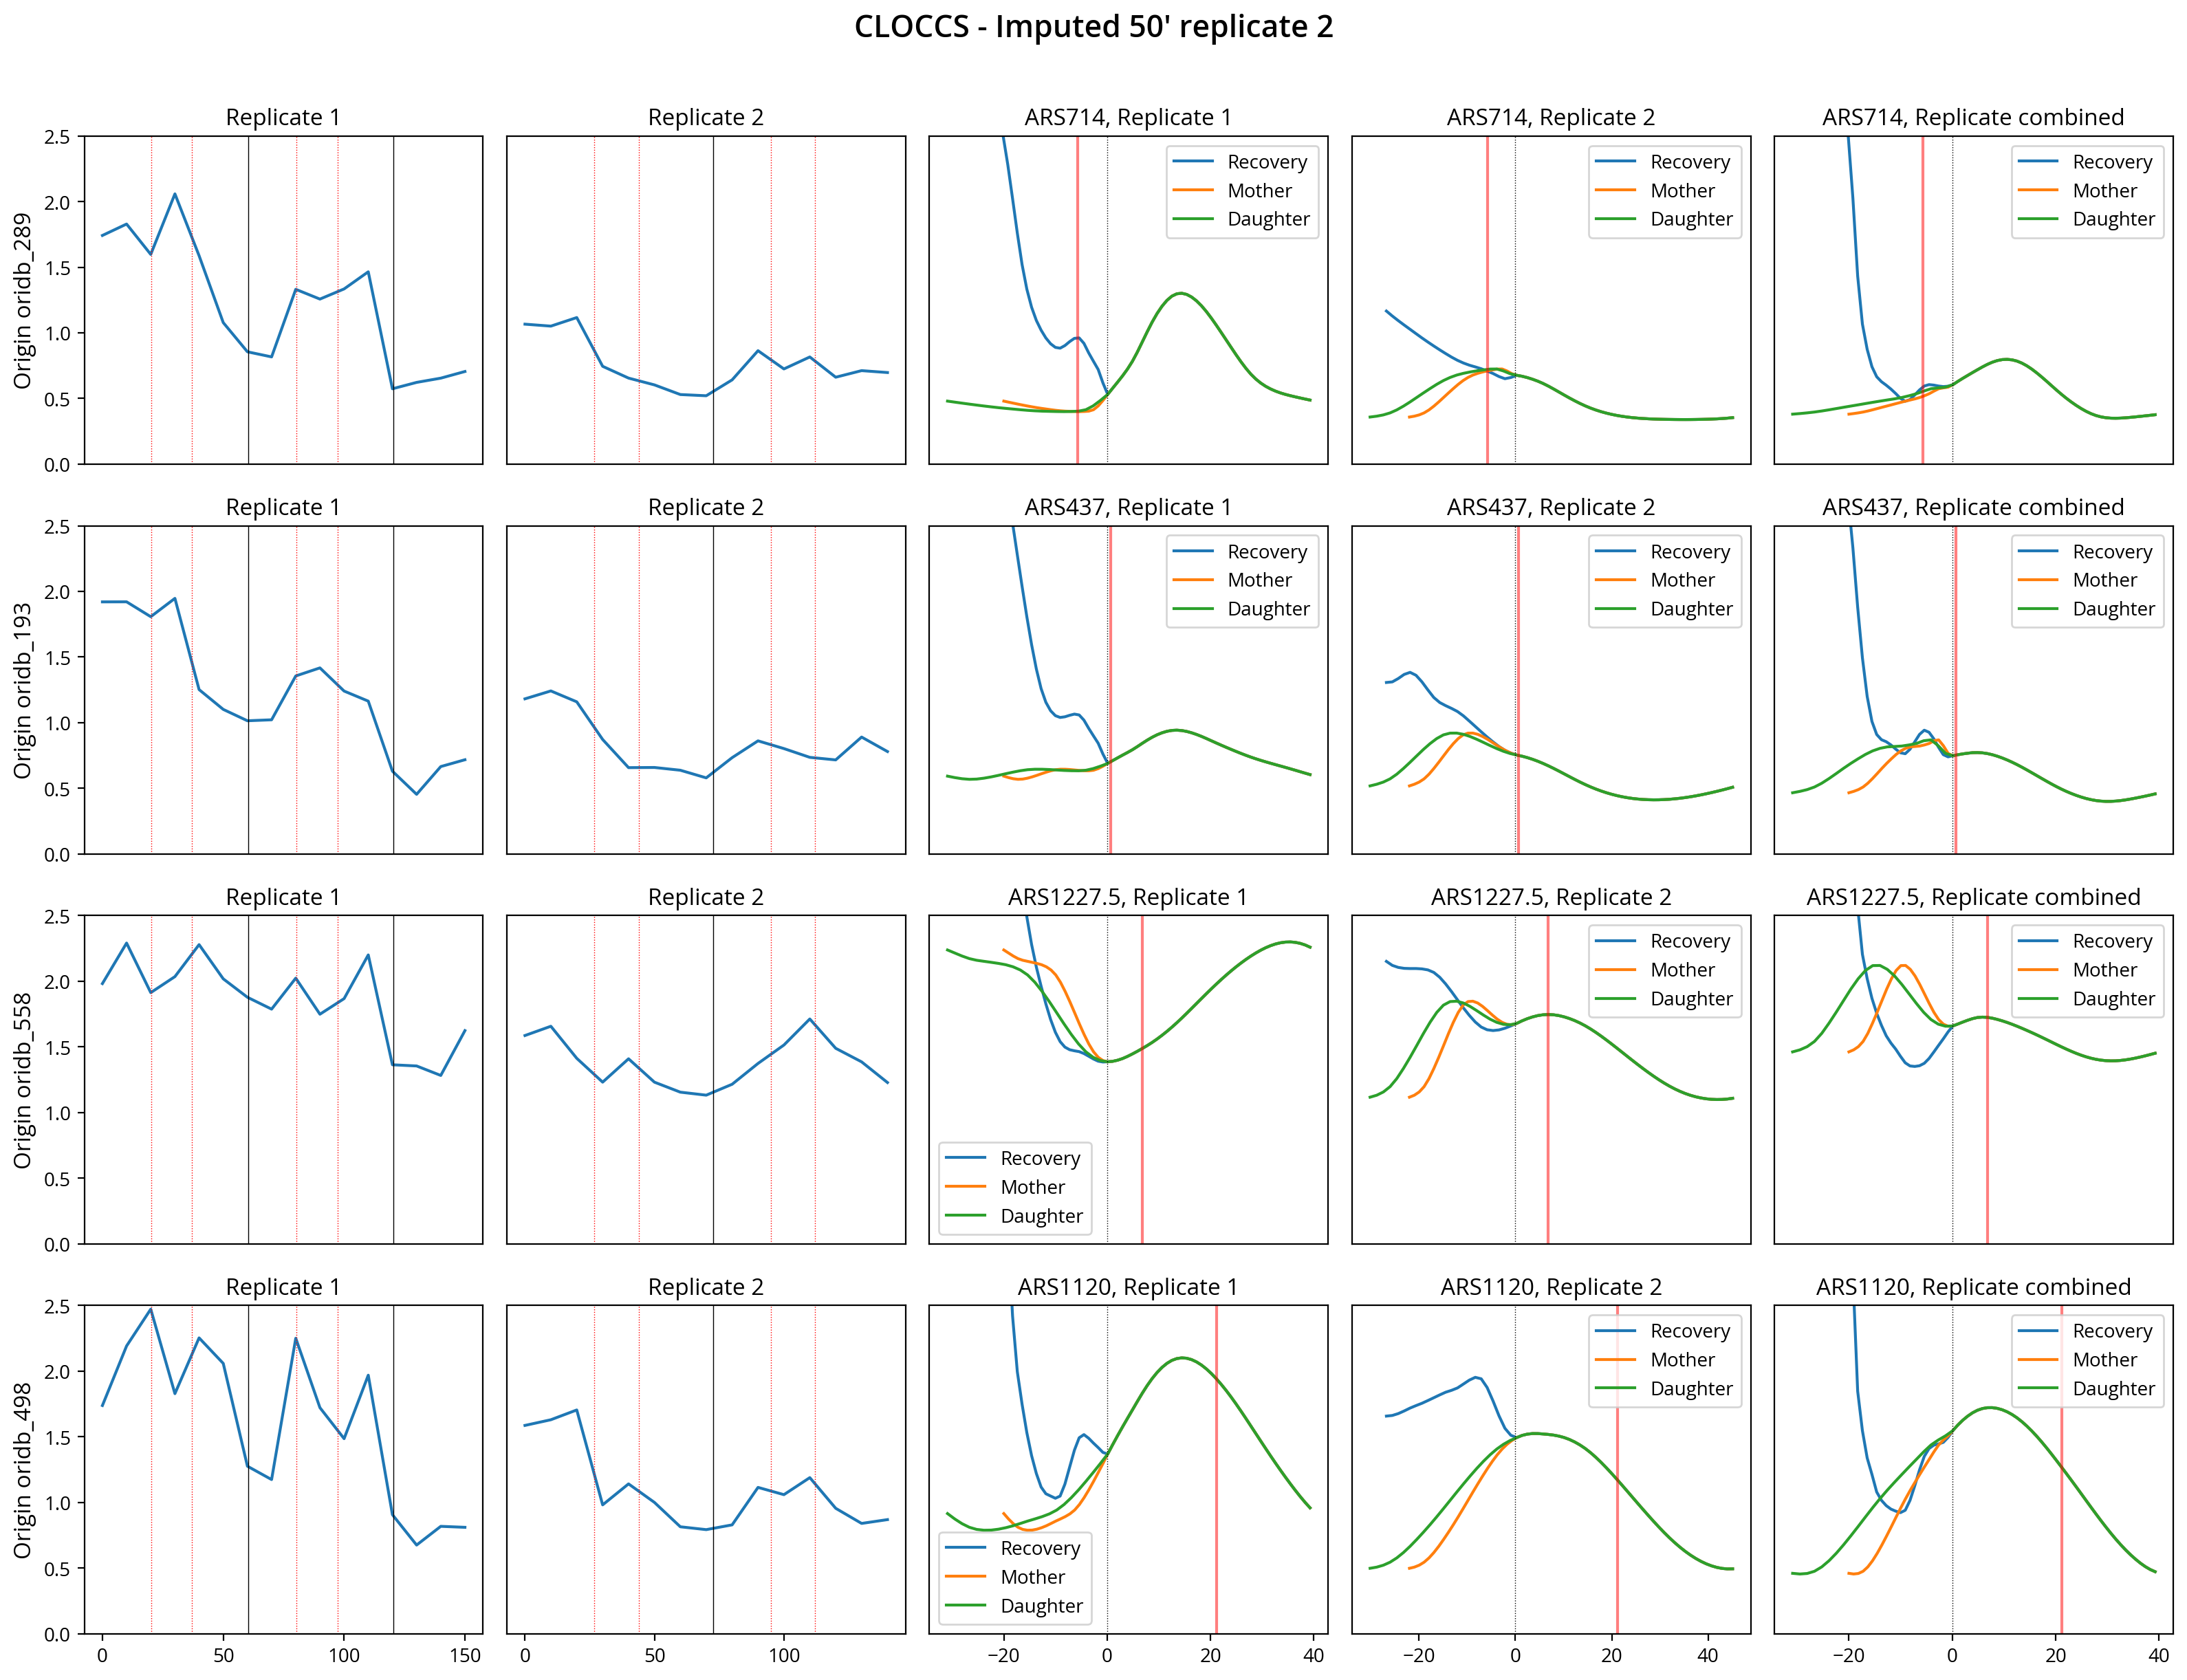

In [1516]:
from pipeline.origin_alpha_sweep import OriginAlphaSweep
import matplotlib.pyplot as plt

# Initialize the sweep object
origin_sweep = OriginAlphaSweep('output/draft3_run/')
    
impute_50s = [False, True]
titles = [
    'CLOCCS - No imputation',
    'CLOCCS - Imputed 50\' replicate 2',
]

# Create one plot per model
for i, impute_50 in enumerate(impute_50s):
    fig = deconvolve_and_plot_model(
        origin_sweep,
        config_mode='cloccs',
        impute_50=impute_50,
        title=titles[i],
        selected_origins=selected_origins,
        gamma=0.0066)
    
    # Display the figure (optional, remove if not needed)
    plt.figure(fig.number)
    plt.show()
    